<a href="https://colab.research.google.com/github/kushalavhad/index.html/blob/main/Experiment_04_Ploting2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment No : 06


##**Aim :**
Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

## Performance :

[Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section]


### Density and Contour plots
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: ``plt.contour`` for contour plots, ``plt.contourf`` for filled contour plots, and ``plt.imshow`` for showing images.

We will see examples of this type of plot in section below

In [7]:
%matplotlib inline

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
import numpy as np

In [8]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the ``plt.contour`` function.
It takes three arguments: a grid of *x* values, a grid of *y* values, and a grid of *z* values.

The *x* and *y* values represent positions on the plot, and the *z* values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the ``np.meshgrid`` function, which builds two-dimensional grids from one-dimensional arrays:

In [9]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

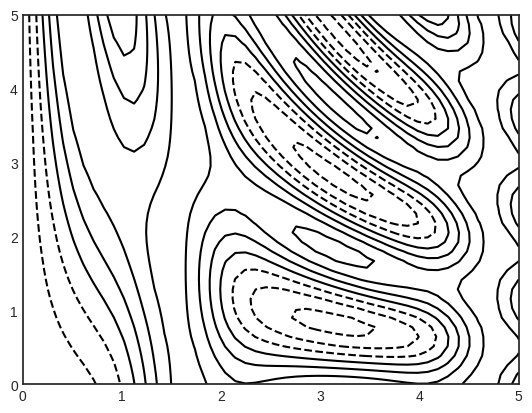

In [10]:
plt.contour(X, Y, Z, colors='black');

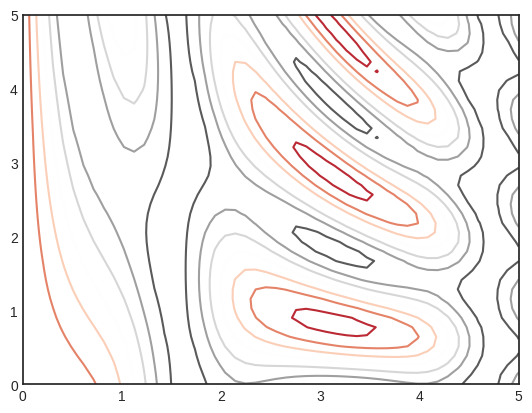

In [11]:
plt.contour(X, Y, Z, cmap='RdGy');

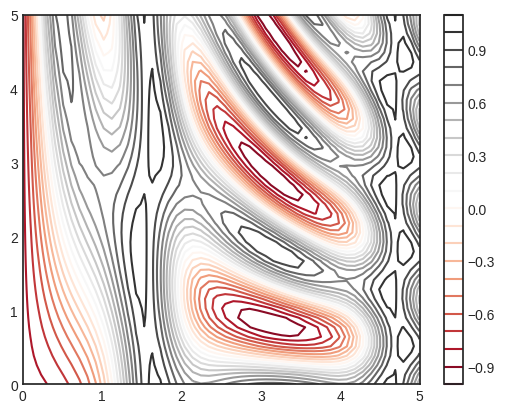

In [12]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

Answer Following Questions :

1.   Explain what are the changes you observe in contour plots above 3 code cells ?

ANS :  

The first plot shows the basic contour, the second changes the color using RdGy, and the third has 20 contour levels with a colorbar.


2. What is size of X, Y and Z respectively ?


The size of X, Y and Z is (256, 256) respectively

*3.* How does colorbar() method help in contour plot.


The colorbar() method is used to display a color scale alongside a contour plot. It helps the user understand the numerical values represented by different colors in the plot.

### Creating Smoother Contour Plots
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level.
A better way to handle this is to use the ``plt.imshow()`` function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

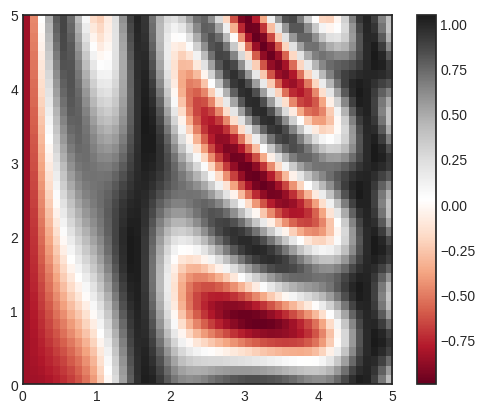

In [13]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.gca().set_aspect('equal')
plt.show()

Things to remember while using ``imshow()``:

- ``plt.imshow()`` doesn't accept an *x* and *y* grid, so you must manually specify the *extent* [*xmin*, *xmax*, *ymin*, *ymax*] of the image on the plot.
- ``plt.imshow()`` by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
- ``plt.imshow()`` will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, ``plt.axis(aspect='image')`` to make *x* and *y* units match.

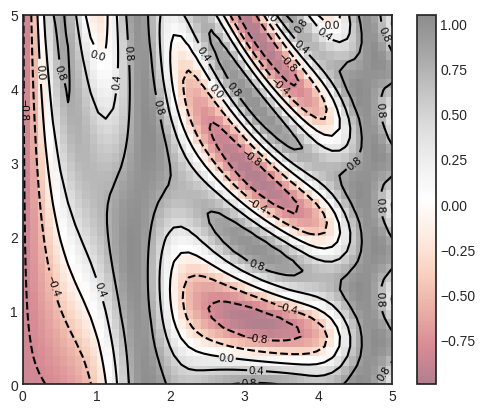

In [14]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

Answer Following Questions :

1.   What does alpha parameter do ?

The alpha parameter controls the transparency of elements in matplotlib plots. It takes a value
between 0.0 (fully transparent) and 1.0 (fully opaque). Here, alpha=0.5 makes the
background image slightly transparent so that the contour lines superimposed on it stand out
clearly.

2.   What does clabel method does ?

The clabel (contour label) method is used to label the contour lines. It places numerical labels
indicating the values represented by each contour line right on the lines themselves.


3.   Recreate above code block after, changing parameter 4 in contour fuction to 5 from 3. Explain what change you see in the plot.  

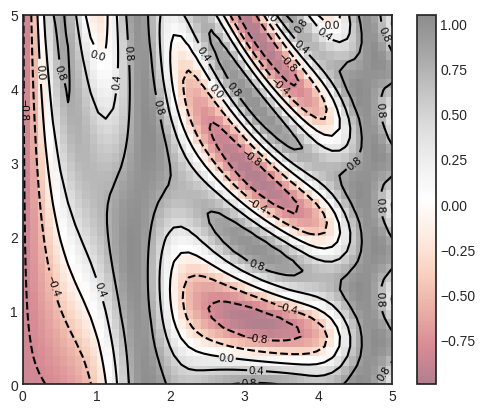

In [15]:
import matplotlib.pyplot as plt

contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
 cmap='RdGy', alpha=0.5)

plt.colorbar();
plt.show()

### Histogram, Binning Plots

A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:



*   The data should be numerical.
*   A histogram is used to check the shape of the data distribution.
*   Used to check whether the process changes from one period to another.
*   Used to determine whether the output is different when it involves two or more processes.
*   Used to analyse whether the given process meets the customer requirements.



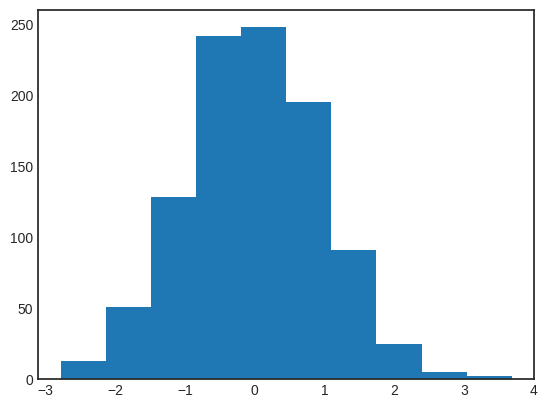

In [16]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The ``hist()`` function has many options to tune both the calculation and the display;
here's an example of a more customized histogram:

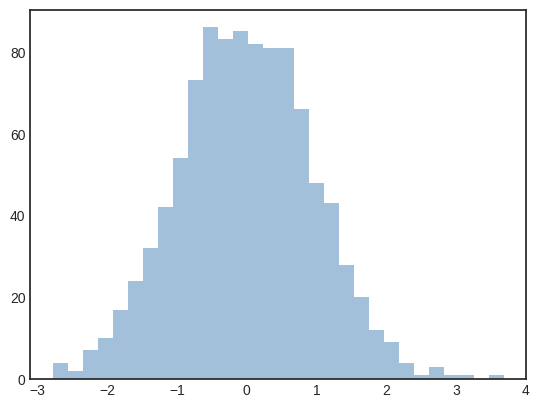

In [17]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The ``plt.hist`` docstring has more information on other customization options available.
I find this combination of ``histtype='stepfilled'`` along with some transparency ``alpha`` to be very useful when comparing histograms of several distributions:

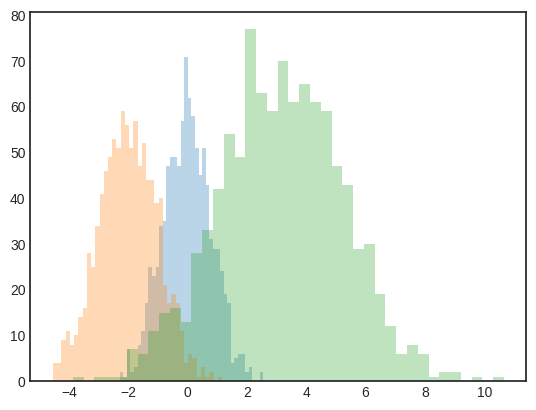

In [18]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the ``np.histogram()`` function is available:

In [19]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 64 370 443 116   7] [-2.7759053  -1.48390135 -0.19189739  1.10010657  2.39211053  3.68411449]


### ``plt.hist2d``: Two-dimensional histogram

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's ``plt.hist2d`` function:

In [20]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

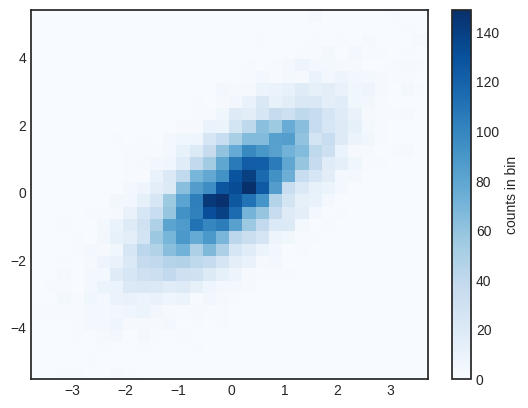

In [21]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with ``plt.hist``, ``plt.hist2d`` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring.
Further, just as ``plt.hist`` has a counterpart in ``np.histogram``, ``plt.hist2d`` has a counterpart in ``np.histogram2d``, which can be used as follows:

In [22]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

### ``plt.hexbin``: Hexagonal binnings

The two-dimensional histogram creates a tesselation of squares across the axes.
Another natural shape for such a tesselation is the regular hexagon.
For this purpose, Matplotlib provides the ``plt.hexbin`` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

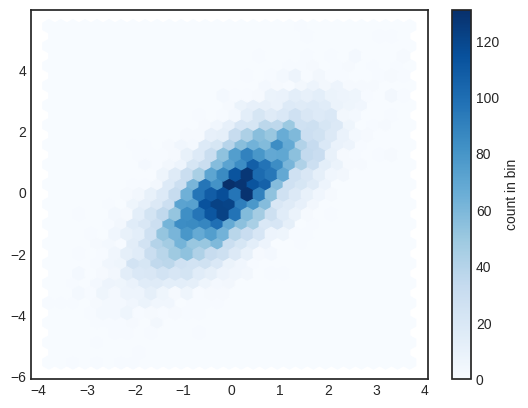

In [23]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

Questions:

1.  What is role of bins parameter in histogram plot?
2.  Create a set of 10000 uniform random samples and store it in variable named *norm_data*. Draw histograms of *norm_data* with following bin counts 5, 50, 500, 5000.
3.  Explain your observations in text box of above step.

### Ploting from a CSV File

In [49]:
# Path to file /content/drive/MyDrive/AIDS1 /notebooks/data/california_cities.csv

In [53]:
from google.colab import files

uploaded = files.upload()

Saving california_cities.csv to california_cities.csv


In [57]:
import os

print(os.listdir('/content'))

['.config', 'drive', 'california_cities.csv', 'births.csv', 'sample_data']


In [61]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'california_cities.csv', 'births.csv', 'sample_data']


In [62]:
import pandas as pd

cities = pd.read_csv('california_cities.csv')

print(cities.head())

   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
2           2      Alameda  37.756111 -122.274444          NaN          33.0   
3           3       Albany  37.886944 -122.297778          NaN          43.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
2             75467            22.960           10.611            12.349   
3             18969             5.465            1.788             3.677   
4             83089             7.632            7.631             0.001   

   area_total_km2  area_land_km2  area_water_km2  area_water_p

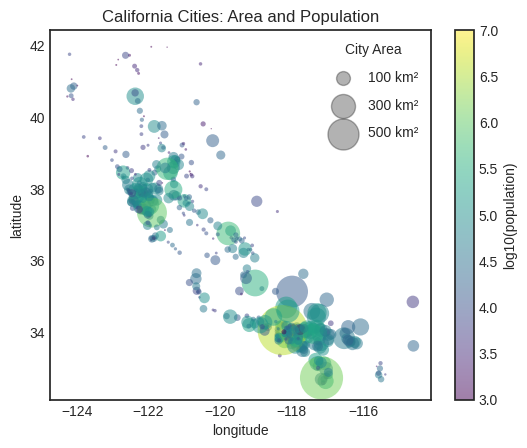

In [63]:
import numpy as np
import matplotlib.pyplot as plt

lat, lon = cities['latd'], cities['longd']
population, area = cities['population_total'], cities['area_total_km2']

plt.scatter(
    lon, lat,
    c=np.log10(population),
    cmap='viridis',
    s=area,
    linewidth=0,
    alpha=0.5
)

plt.gca().set_aspect('equal')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log10(population)')
plt.clim(3, 7)

for area in [100, 300, 500]:
    plt.scatter(
        [], [],
        c='k',
        alpha=0.3,
        s=area,
        label=str(area) + ' km²'
    )

plt.legend(
    scatterpoints=1,
    frameon=False,
    labelspacing=1,
    title='City Area'
)

plt.title('California Cities: Area and Population')
plt.show()

### Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of *subplots* : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [67]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-white')

### ``plt.axes``: Subplots by Hand (Coding)

The most basic method of creating an axes is to use the ``plt.axes`` function. By default this creates a standard axes object that fills the entire figure.

``plt.axes`` also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent
``[left, bottom, width, height]`` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the *x* and *y* position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the *x* and *y* extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

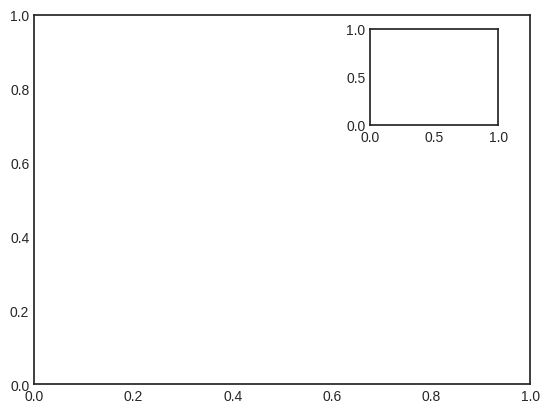

In [68]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

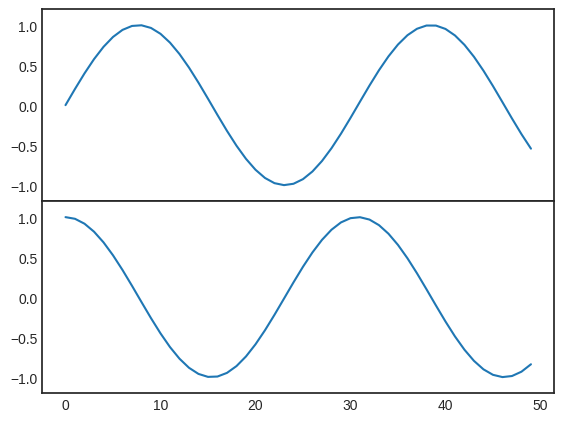

In [69]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

### ``plt.subplot``: Simple Grids of Subplots

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is ``plt.subplot()``, which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

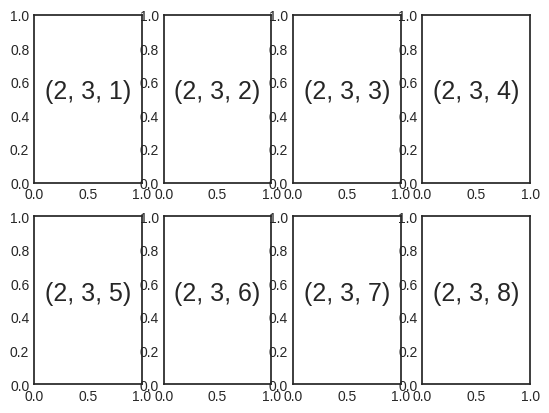

In [70]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')


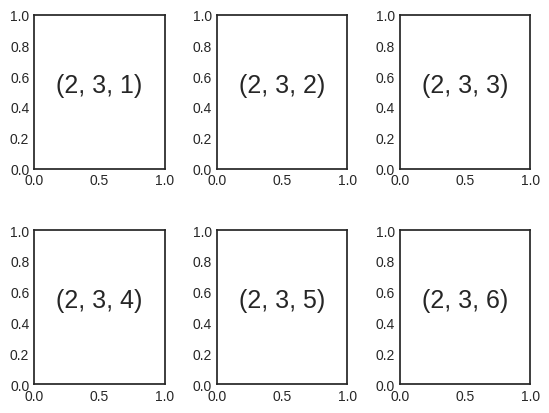

In [71]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

### ``plt.subplots``: The Whole Grid in One Go

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots.
For this purpose, ``plt.subplots()`` is the easier tool to use (note the ``s`` at the end of ``subplots``). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array.
The arguments are the number of rows and number of columns, along with optional keywords ``sharex`` and ``sharey``, which allow you to specify the relationships between different axes.

Here we'll create a $2 \times 3$ grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

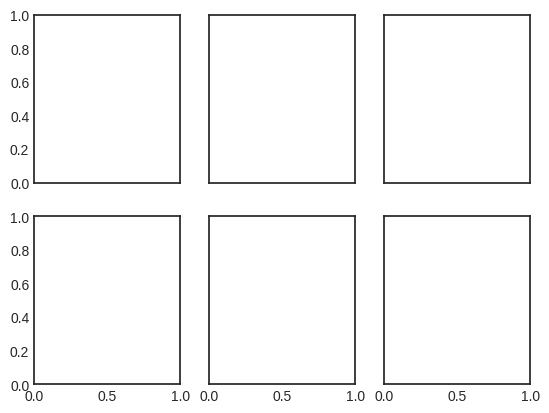

In [72]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying ``sharex`` and ``sharey``, we've automatically removed inner labels on the grid to make the plot cleaner.


The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

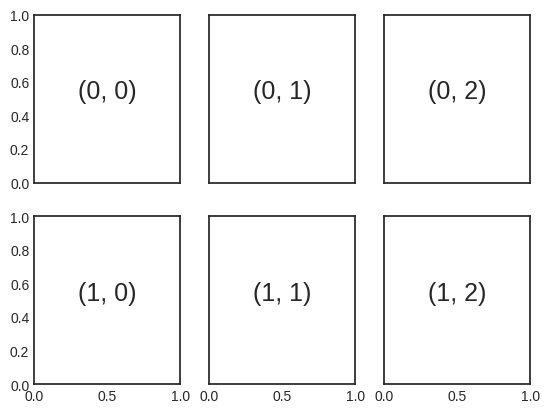

In [73]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

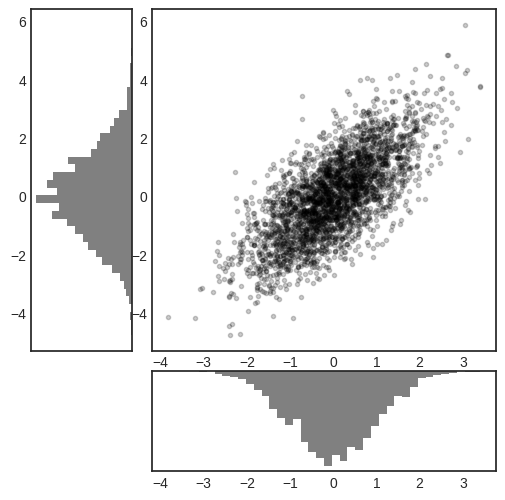

In [74]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


In [76]:
from google.colab import files

uploaded = files.upload()

Saving births.csv to births (1).csv


In [78]:
import pandas as pd
import numpy as np
import matplotlib as mpl

# Read the uploaded CSV file
births = pd.read_csv('births.csv')

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])

births = births.query(
    '(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)'
)

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(
    10000 * births.year +
    100 * births.month +
    births.day,
    format='%Y%m%d'
)

births_by_date = births.pivot_table(
    'births',
    [births.index.month, births.index.day]
)

# Modern replacement for pd.datetime
births_by_date.index = [
    pd.Timestamp(2012, month, day)
    for (month, day) in births_by_date.index
]

In [82]:
import pandas as pd
import numpy as np
import matplotlib as mpl

# Read the uploaded CSV file
births = pd.read_csv('births.csv')

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])

births = births.query(
    '(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)'
)

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(
    10000 * births.year +
    100 * births.month +
    births.day,
    format='%Y%m%d'
)

births_by_date = births.pivot_table(
    'births',
    [births.index.month, births.index.day]
)

# Modern replacement for pd.datetime
births_by_date.index = [
    pd.Timestamp(2012, month, day)
    for (month, day) in births_by_date.index
]

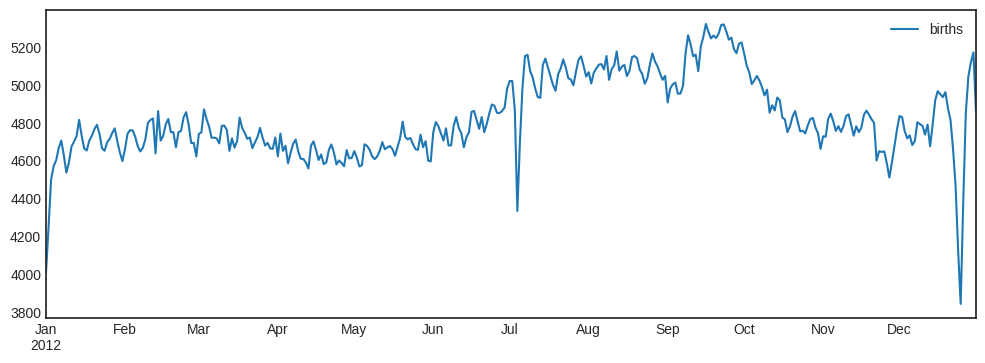

In [84]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);


### Boxplot

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.



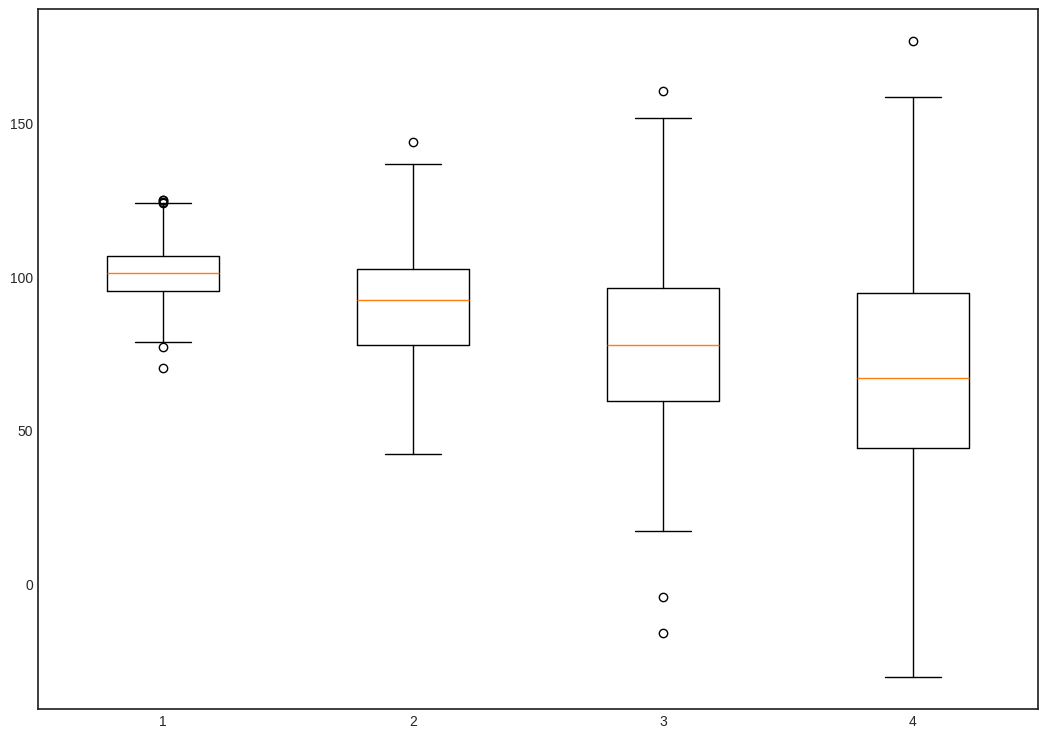

In [85]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()


Questions:

1. What is boxplot ?

A Box Plot (or box-and-whisker plot) is a standardized way of displaying the distribution of data
based on a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3),
and maximum.

2. What information do we get from a box plot?

We get information about the range, dispersion, symmetry, and median of the dataset. It helps
visualize key metrics:
• Median: The central line dividing the box.
• IQR (Interquartile Range): The middle 50% of the data represented by the box length
(Q3 - Q1).
• Whiskers: Indicate variability outside the upper and lower quartiles.
• Outliers: Points plotted individually outside the whiskers.

3. How is minimum and maximum whisker's marked in a box plot ?

By default in Matplotlib, whiskers extend from the box to the farthest data points that lie within
1.5×IQR (Interquartile Range) from the edges of the box (Q 1−1.5×IQR for the lower whisker,
and Q 3+1.5×IQR for the upper whisker). Caps are drawn as horizontal lines marking these
boundaries.


4. How to we identify that some points in data are outliers by viewing the box plot?

Any data points that lie beyond the whiskers (further than 1.5×IQR away from the quartiles) are
flagged as outliers and are plotted individually as distinct points (often dots, circles, or asterisks)
outside the boundaries of the whiskers.

5. Read a data file from your drive and for all numeric columns plot boxplot.



## Conclusion
Thus we have learned about basics of  Contour plots, Histograms, Box plots.